# Herramienta de Regresión Auditada — Costo médico anual por asegurado

**MAI 540 — Tarea 4.2 · Carlo E. Alicea Medina**

**Problema (sector salud).** Se predice el **costo médico anual** de un asegurado (variable continua, en **dólares estadounidenses, USD**) a partir de edad, sexo, índice de masa corporal (IMC), número de hijos, hábito de fumar y región. La predicción apoyaría una decisión de **planificación de reservas y priorización de programas preventivos** (por ejemplo, a quién ofrecer primero un programa para dejar de fumar), **no** la fijación individual de primas ni la negación de cobertura. El error se expresa en USD por asegurado y año.

**Datos.** Conjunto **sintético** de 1,500 filas generado con semilla fija dentro de este notebook, con la misma estructura del dataset público *Medical Cost Personal* (`insurance.csv`), que no pudo descargarse en el entorno de trabajo. Incluye a propósito:
- una **columna de fuga**, `monto_reembolsado_aseguradora` (se conoce solo después de facturar el costo), marcada como **prohibida** en `contexto_proyecto.md`;
- **subgrupos**: `fumador` y `region`;
- valores faltantes en `imc` y `hijos` (requieren imputación).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42

## 1. Datos

In [2]:
def generar_datos(n=1500, semilla=42):
    """Dataset sintético inspirado en Medical Cost Personal (insurance.csv). Costo anual en USD."""
    r = np.random.RandomState(semilla)
    region = r.choice(['northeast', 'northwest', 'southeast', 'southwest'], n, p=[0.24, 0.24, 0.28, 0.24])
    edad = r.randint(18, 65, n)
    sexo = r.choice(['female', 'male'], n)
    imc = np.clip(r.normal(30.5, 6, n) + np.where(region == 'southeast', 2.0, 0), 16, 53).round(2)
    hijos = np.clip(r.poisson(1.1, n), 0, 5)
    fumador = r.choice(['no', 'yes'], n, p=[0.8, 0.2])
    es_f = fumador == 'yes'
    costo = (2500 + 260 * edad + 450 * hijos + 60 * (imc - 30)
             + es_f * (11500 + 20000 * (imc >= 30))
             + r.normal(0, 2500, n)
             + (r.rand(n) < 0.07) * r.gamma(2, 5000, n))          # condiciones no observadas
    costo = np.clip(costo, 1100, None).round(2)
    df = pd.DataFrame({'edad': edad, 'sexo': sexo, 'imc': imc, 'hijos': hijos.astype(float),
                       'fumador': fumador, 'region': region, 'costo_medico_anual': costo})
    # Columna de FUGA (prohibida): se conoce solo DESPUÉS de facturar el costo
    df['monto_reembolsado_aseguradora'] = (df['costo_medico_anual'] * r.uniform(0.70, 0.90, n)).round(2)
    # Faltantes realistas (requieren imputación)
    df.loc[r.rand(n) < 0.03, 'imc'] = np.nan
    df.loc[r.rand(n) < 0.02, 'hijos'] = np.nan
    return df


df = generar_datos(n=1500, semilla=RANDOM_STATE)
print(df.shape)
print(df.isna().sum()[df.isna().sum() > 0])
df.head()

(1500, 8)
imc      47
hijos    35
dtype: int64


   edad    sexo  ...  costo_medico_anual  monto_reembolsado_aseguradora
0    19    male  ...             9863.52                        7924.90
1    23    male  ...            44044.05                       38221.55
2    45  female  ...            14410.31                       12189.24
3    46    male  ...            17922.18                       13869.47
4    43  female  ...            27318.35                       22692.99

[5 rows x 8 columns]

## 2. Partición (antes de cualquier preprocesamiento)

La columna de fuga se excluye de los predictores (regla del archivo de contexto). La división 80/20 con semilla fija se hace **antes** de imputar, codificar o escalar; todo lo que aprende de los datos va dentro de un `Pipeline` que se ajusta solo con entrenamiento.

In [3]:
OBJETIVO = 'costo_medico_anual'
COLUMNA_FUGA = 'monto_reembolsado_aseguradora'   # PROHIBIDA: se conoce después del resultado
NUMERICAS = ['edad', 'imc', 'hijos']
CATEGORICAS = ['sexo', 'fumador', 'region']
PREDICTORES = NUMERICAS + CATEGORICAS
assert COLUMNA_FUGA not in PREDICTORES

X = df[PREDICTORES]
y = df[OBJETIVO]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Entrenamiento: {len(X_train)} filas | Prueba: {len(X_test)} filas")
print(f"Rango del objetivo en entrenamiento: {y_train.min():,.0f} a {y_train.max():,.0f} USD")

Entrenamiento: 1200 filas | Prueba: 300 filas
Rango del objetivo en entrenamiento: 2,809 a 66,640 USD


### Corrección tras la auditoría (hallazgo V4.2: disparidad del error por `fumador`)

La primera auditoría (`auditoria/AUDIT_REPORT_antes.md`) marcó FALLA en disparidad: el error de los fumadores era varias veces el global. Los residuos mostraban la causa: el costo de un fumador salta cuando su IMC ≥ 30, y la regresión lineal solo suma efectos, así que no puede representar esa interacción. **Corrección:** se agregan dos variables derivadas **dentro del pipeline** (no usan el objetivo ni datos de prueba): `fumador_obeso` = fumador × (IMC ≥ 30) y `fumador_x_imc`. La partición, los modelos y los hiperparámetros no cambian.

In [4]:
from sklearn.preprocessing import FunctionTransformer

def agregar_interacciones(X):
    """Interacciones fumador × IMC. Solo usa columnas de entrada de la misma fila: no aprende de los datos."""
    X = X.copy()
    es_fumador = (X['fumador'] == 'yes').astype(float)
    X['fumador_obeso'] = es_fumador * (X['imc'] >= 30)
    X['fumador_x_imc'] = es_fumador * X['imc'].fillna(X['imc'].median() if len(X) > 1 else 30)
    return X

NUMERICAS = NUMERICAS + ['fumador_obeso', 'fumador_x_imc']

## 3. Tres modelos sobre la misma partición

In [5]:
def crear_preprocesador():
    return ColumnTransformer([
        ('num', Pipeline([('imputar', SimpleImputer(strategy='median')), ('escalar', StandardScaler())]), NUMERICAS),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), CATEGORICAS),
    ])

modelos = {
    'Referencia (media)': DummyRegressor(strategy='mean'),
    'Regresión lineal': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
}

filas, ajustados = [], {}
for nombre, estimador in modelos.items():
    pipe = Pipeline([('interacciones', FunctionTransformer(agregar_interacciones)), ('prep', crear_preprocesador()), ('modelo', estimador)])
    pipe.fit(X_train, y_train)                     # todo el preprocesamiento aprende SOLO de entrenamiento
    ajustados[nombre] = pipe
    pred_te, pred_tr = pipe.predict(X_test), pipe.predict(X_train)
    mse = mean_squared_error(y_test, pred_te)
    filas.append({'Modelo': nombre, 'MSE': mse, 'RMSE (USD)': np.sqrt(mse),
                  'R² prueba': r2_score(y_test, pred_te), 'R² entrenamiento': r2_score(y_train, pred_tr)})
tabla = pd.DataFrame(filas)
rmse_ref = tabla.loc[0, 'RMSE (USD)']
tabla['Mejora RMSE vs. referencia'] = 1 - tabla['RMSE (USD)'] / rmse_ref
pd.set_option('display.float_format', lambda v: f'{v:,.4f}' if abs(v) < 10 else f'{v:,.0f}')
print(tabla.to_string(index=False))
mejor = tabla.iloc[1:].sort_values('RMSE (USD)').iloc[0]['Modelo']
print(f"\nMejor modelo (menor RMSE de prueba): {mejor}")

            Modelo         MSE  RMSE (USD)  R² prueba  R² entrenamiento  Mejora RMSE vs. referencia
Referencia (media) 119,538,775      10,933    -0.0102            0.0000                      0.0000
  Regresión lineal  13,289,938       3,646     0.8877            0.8767                      0.6666
     Random Forest  15,124,675       3,889     0.8722            0.9214                      0.6443

Mejor modelo (menor RMSE de prueba): Regresión lineal


**Interpretación (después de la corrección).**
- **RMSE en unidades reales.** El mejor modelo pasa a ser la **regresión lineal con interacciones**, que se equivoca en promedio unos **3,646 USD por asegurado y año**, frente a 10,933 USD de la referencia trivial. El Random Forest queda en 3,889 USD.
- **R².** La lineal explica el **88.8 %** de la variación del costo en prueba y el Random Forest el **87.2 %**.
- **Por qué no basta una sola métrica.** Un R² de 0.89 suena excelente, pero 3,600 USD de error por persona sigue siendo mucho para un asegurado de bajo costo (≈ 25 % de un costo típico de 14,000 USD). Y un RMSE solo, sin R², no dice cuánto de la variabilidad ya se capturó.
- **Mejora frente a la referencia.** El RMSE baja un **67 %** (lineal) y un **64 %** (Random Forest).
- **Sobreajuste.** Lineal: R² de 0.877 en entrenamiento y 0.888 en prueba, sin sobreajuste. Random Forest: 0.921 frente a 0.872 (brecha de 0.05, leve). Con la interacción explícita, el modelo simple iguala y supera al complejo.

## 4. Residuos del mejor modelo

Residuo medio y desviación por tercil de predicción:
        mean   std  count
tercil                   
bajo     102 3,401    100
medio    100 3,514    100
alto    -399 4,021    100

Asimetría de residuos: 2.06 | residuos > 10,000 USD: 5 de 300


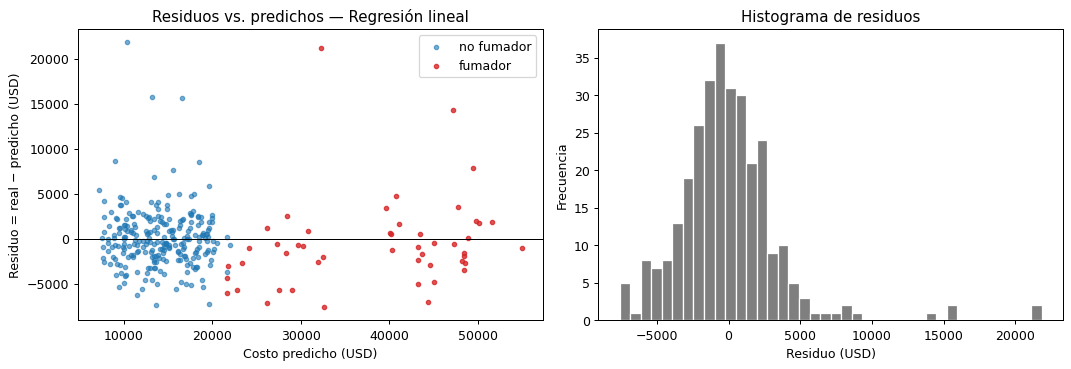

In [6]:
pred = ajustados[mejor].predict(X_test)
residuos = y_test - pred
es_fum = X_test['fumador'] == 'yes'
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].scatter(pred[~es_fum], residuos[~es_fum], s=12, alpha=0.6, label='no fumador')
ax[0].scatter(pred[es_fum], residuos[es_fum], s=12, alpha=0.8, color='tab:red', label='fumador')
ax[0].axhline(0, color='black', lw=0.8)
ax[0].set_xlabel('Costo predicho (USD)'); ax[0].set_ylabel('Residuo = real − predicho (USD)')
ax[0].set_title(f'Residuos vs. predichos — {mejor}'); ax[0].legend()
ax[1].hist(residuos, bins=40, color='tab:gray', edgecolor='white')
ax[1].set_xlabel('Residuo (USD)'); ax[1].set_ylabel('Frecuencia'); ax[1].set_title('Histograma de residuos')
plt.tight_layout(); plt.show()

tercil = pd.qcut(pred, 3, labels=['bajo', 'medio', 'alto'])
print("Residuo medio y desviación por tercil de predicción:")
print(pd.DataFrame({'res': residuos.values, 'tercil': tercil}).groupby('tercil', observed=True)['res'].agg(['mean', 'std', 'count']).round(0))
print(f"\nAsimetría de residuos: {residuos.skew():.2f} | residuos > 10,000 USD: {(residuos > 10000).sum()} de {len(residuos)}")

**Lectura de los residuos (regresión lineal corregida).** La curvatura desapareció: el residuo medio por tercil de predicción es +102, +100 y −399 USD, cerca de cero en los tres. Quedan dos patrones:
1. **La dispersión crece con el valor predicho** (desviación de 3,401 USD en el tercil bajo frente a 4,021 USD en el alto): hay heterocedasticidad.
2. **Cola larga a la derecha** (asimetría 2.06; 5 residuos > 10,000 USD): son asegurados con costos extraordinarios (condiciones no observadas) que el modelo subestima sistemáticamente.

El modelo no captura esa estructura porque ninguna variable disponible la describe. Una transformación logarítmica del objetivo o más variables clínicas serían los siguientes pasos.

## 5. RMSE por subgrupo (alimenta la verificación de disparidad)

In [7]:
def rmse_por_subgrupo(nombre, columna):
    pred = ajustados[nombre].predict(X_test)
    glob = np.sqrt(mean_squared_error(y_test, pred))
    filas = []
    for g, idx in X_test.groupby(columna).groups.items():
        r = np.sqrt(mean_squared_error(y_test.loc[idx], pred[X_test.index.get_indexer(idx)]))
        filas.append({'Modelo': nombre, 'Columna': columna, 'Subgrupo': g, 'n': len(idx), 'RMSE (USD)': r,
                      'RMSE / global': r / glob, 'Costo medio (USD)': y_test.loc[idx].mean()})
    return filas

sub = pd.DataFrame([f for m in ['Regresión lineal', 'Random Forest'] for c in ['fumador', 'region'] for f in rmse_por_subgrupo(m, c)])
print(sub.round(3).to_string(index=False))

          Modelo Columna  Subgrupo   n  RMSE (USD)  RMSE / global  Costo medio (USD)
Regresión lineal fumador        no 251       3,313         0.9090             14,142
Regresión lineal fumador       yes  49       5,015         1.3760             37,688
Regresión lineal  region northeast  79       2,405         0.6600             15,883
Regresión lineal  region northwest  71       4,919         1.3490             19,419
Regresión lineal  region southeast  76       3,793         1.0400             18,784
Regresión lineal  region southwest  74       3,117         0.8550             18,044
   Random Forest fumador        no 251       3,567         0.9170             14,142
   Random Forest fumador       yes  49       5,238         1.3470             37,688
   Random Forest  region northeast  79       3,770         0.9690             15,883
   Random Forest  region northwest  71       4,368         1.1230             19,419
   Random Forest  region southeast  76       4,023         1.0340

## 6. Antes y después de la corrección

Valores del notebook **antes** de la corrección tomados de `auditoria/AUDIT_REPORT_antes.md` (misma partición y semilla).

In [8]:
antes = pd.DataFrame({'Modelo': ['Referencia (media)', 'Regresión lineal', 'Random Forest'],
                      'RMSE antes': [10933, 5360, 3892], 'R² antes': [-0.0102, 0.7572, 0.8720]})
despues = tabla[['Modelo', 'RMSE (USD)', 'R² prueba']].rename(columns={'RMSE (USD)': 'RMSE después', 'R² prueba': 'R² después'})
comp = antes.merge(despues, on='Modelo')
fum = sub[(sub['Columna'] == 'fumador')].pivot(index='Modelo', columns='Subgrupo', values='RMSE / global')
print(comp.to_string(index=False))
print("\nRMSE fumadores / RMSE global (después):")
print(fum.round(2))

            Modelo  RMSE antes  R² antes  RMSE después  R² después
Referencia (media)       10933   -0.0102        10,933     -0.0102
  Regresión lineal        5360    0.7572         3,646      0.8877
     Random Forest        3892    0.8720         3,889      0.8722

RMSE fumadores / RMSE global (después):
Subgrupo             no    yes
Modelo                        
Random Forest    0.9200 1.3500
Regresión lineal 0.9100 1.3800


## 7. Limitaciones y condiciones de no uso

- **Rango de entrenamiento (no extrapolar).** Costo de 2,809 a 66,640 USD; edad de 18 a 64 años; IMC de 16 a 53; de 0 a 5 hijos. No debe usarse para menores de 18, mayores de 64 ni para estimar costos fuera de ese rango.
- **Subgrupos con mayor error.** Fumadores: RMSE de 5,015 USD, 1.38 veces el global (aunque su error relativo es menor: 13 % de su costo medio, frente a 23 % en no fumadores). Región *northwest*: 1.35 veces el global. Asegurados con costos extraordinarios (residuos > 10,000 USD): el modelo los subestima.
- **Variables que cambian con el tiempo.** Inflación médica (los USD corresponden a un año de referencia), prevalencia de tabaquismo y obesidad, y la cobertura y los precios de cada región. El modelo debe reentrenarse si cambian.
- **No usar para:**
  - fijar primas individuales o negar cobertura (el modelo usa sexo y región, y la ley puede restringir esas variables);
  - decisiones clínicas;
  - poblaciones de otros sistemas de salud;
  - cualquier decisión real mientras se base en **datos sintéticos**: primero hay que reentrenarlo y validarlo con datos reales.
- **Sí es adecuado para:** estimar reservas agregadas y priorizar a quién ofrecer programas preventivos, siempre con revisión humana.